# Análisis de Riesgo Hídrico - San Juan del Río, Qro.
## Fase 1: Extracción y Limpieza de Datos Espaciales
En esta sección cargamos los datos geográficos exportados desde ArcMap. El objetivo es validar la integridad de la información, asegurando que no existan valores nulos en la columna `grid_code`, la cual representa la acumulación de flujo hídrico.

In [22]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Cargar los datos vectoriales (SHP)
# Asegúrate de que el archivo esté en la misma carpeta que tu notebook
gdf = gpd.read_file('escurrimientos_sjr.shp')

# 2. Limpieza y validación de integridad
# Eliminamos geometrías vacías que podrían causar errores en los cálculos espaciales
gdf = gdf[gdf.geometry.notnull()]

# Verificamos la calidad de la columna técnica 'grid_code' (acumulación de flujo)
nulos = gdf['grid_code'].isnull().sum()

print("ESTADO DE LA BASE DE DATOS:")
print("-" * 30)
print(gdf.info())
print(f"\nRegistros totales cargados: {len(gdf)}")
print(f"Valores nulos detectados: {nulos}")

# Visualización previa de los datos crudos
gdf.head()

ESTADO DE LA BASE DE DATOS:
------------------------------
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 14877 entries, 0 to 14876
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   OBJECTID    14877 non-null  int64   
 1   arcid       14877 non-null  int64   
 2   grid_code   14877 non-null  int64   
 3   from_node   14877 non-null  int64   
 4   to_node     14877 non-null  int64   
 5   Shape_Leng  14877 non-null  float64 
 6   geometry    14877 non-null  geometry
dtypes: float64(1), geometry(1), int64(5)
memory usage: 813.7 KB
None

Registros totales cargados: 14877
Valores nulos detectados: 0


,OBJECTID,arcid,grid_code,from_node,to_node,Shape_Leng,geometry
0,62,62,1938,113,114,25.0,"LINESTRING (378250 2267700, 378250 2267725)"
1,92,92,2291,164,165,25.0,"LINESTRING (380350 2267700, 380350 2267725)"
2,187,187,18829,352,353,25.0,"LINESTRING (385600 2267700, 385600 2267725)"
3,219,219,6042,429,430,25.0,"LINESTRING (388100 2267700, 388100 2267725)"
4,220,220,683,431,429,50.0,"LINESTRING (388150 2267700, 388100 2267700)"


## Fase 2 : Ingeniería de Variables y Análisis de Vulnerabilidad

En esta sección, integramos el procesamiento técnico con el análisis descriptivo para transformar datos crudos en indicadores de decisión. Este flujo comprende:

1. **Normalización del flujo**: Escalamos el valor `grid_code` (acumulación de flujo) a un **Índice de Peligrosidad** en una escala de 0 a 100.
2. **Categorización de Riesgo**: Clasificamos estadísticamente cada segmento de la red en cuatro niveles: **Bajo, Medio, Alto y Crítico**.
3. **Análisis de Vulnerabilidad**: Realizamos una agrupación y cálculo porcentual para determinar el impacto real sobre el municipio de **San Juan del Río**.

Estos resultados son fundamentales para priorizar la supervisión de infraestructura civil y la gestión de riesgos regionales en Querétaro.

In [23]:
# --- FASE 2: INGENIERÍA DE VARIABLES ---
# Calculamos el índice de peligro normalizado
max_f, min_f = gdf['grid_code'].max(), gdf['grid_code'].min()
gdf['indice_peligro'] = ((gdf['grid_code'] - min_f) / (max_f - min_f)) * 100

# Re-clasificación adaptada a la vulnerabilidad urbana
def clasificar_riesgo_urbano(valor):
    if valor <= 0.5: return '1. Despreciable'
    if valor <= 2:   return '2. Moderado (Calle)'
    if valor <= 5:   return '3. Alto (Avenida)'
    return '4. Crítico (Cauce/Río)'

gdf['nivel_riesgo'] = gdf['indice_peligro'].apply(clasificar_riesgo_urbano)

# Agrupamos y calculamos porcentajes
resumen = gdf.groupby('nivel_riesgo').size().reset_index(name='Total_Segmentos')
resumen['Porcentaje'] = (resumen['Total_Segmentos'] / len(gdf)) * 100

# Mostramos el resultado final inmediatamente
print("ANÁLISIS DE VULNERABILIDAD HÍDRICA - MUNICIPIO SJR")
print("-" * 50)
print(resumen.sort_values(by='nivel_riesgo', ascending=False).to_string(index=False))

ANÁLISIS DE VULNERABILIDAD HÍDRICA - MUNICIPIO SJR
--------------------------------------------------
          nivel_riesgo  Total_Segmentos  Porcentaje
4. Crítico (Cauce/Río)             4357   29.286819
     3. Alto (Avenida)             2284   15.352558
   2. Moderado (Calle)             3993   26.840089
       1. Despreciable             4243   28.520535


## Fase 3: Validación Estadística (Análisis de Distribución)
Para asegurar la fiabilidad del modelo, generamos un histograma del **Índice de Peligrosidad**. 
Esta prueba permite:
1. **Identificar sesgos**: Verificar si la mayoría de los datos se concentran en niveles bajos, como es común en redes hídricas naturales.
2. **Detectar Outliers**: Confirmar que los valores "Críticos" son significativos y no errores de medición.

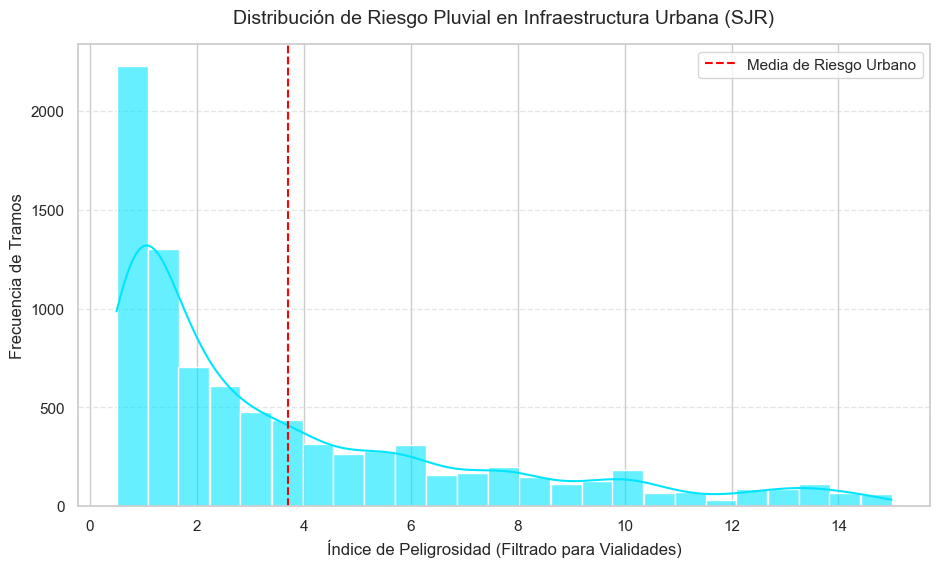

Total de segmentos analizados en zona urbana: 8591
Promedio del índice en calles: 3.71


In [26]:
# 1. Filtro de datos para coherencia estadística
# Usamos el rango 0.5 a 15 que define nuestra "Zona de Riesgo Vial"
df_stats_urbano = gdf[(gdf['indice_peligro'] > 0.5) & (gdf['indice_peligro'] <= 15)].copy()

# 2. Creación del histograma corregido
plt.figure(figsize=(11, 6))
sns.histplot(df_stats_urbano['indice_peligro'], 
             kde=True, 
             color='#00e5ff', 
             bins=25, 
             alpha=0.6)

# 3. Estética profesional
plt.title('Distribución de Riesgo Pluvial en Infraestructura Urbana (SJR)', fontsize=14, pad=15)
plt.xlabel('Índice de Peligrosidad (Filtrado para Vialidades)', fontsize=12)
plt.ylabel('Frecuencia de Tramos', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Añadimos una línea vertical para marcar el promedio
plt.axvline(df_stats_urbano['indice_peligro'].mean(), color='red', linestyle='--', label='Media de Riesgo Urbano')
plt.legend()

plt.show()

print(f"Total de segmentos analizados en zona urbana: {len(df_stats_urbano)}")
print(f"Promedio del índice en calles: {df_stats_urbano['indice_peligro'].mean():.2f}")

## Fase 4: Análisis de Sensibilidad y Enfoque Urbano

Para optimizar el valor del estudio para la toma de decisiones en infraestructura civil, se ha realizado un proceso de filtrado de datos (poda de base). Este refinamiento permite:

1. **Eliminar el ruido estadístico**: Descartar escurrimientos menores con un índice inferior a 20 que no representan riesgo de inundación.
2. **Excluir cauces naturales consolidados**: Al limitar el índice superior a 75, se omiten los ríos y grandes arroyos fuera de la mancha urbana, los cuales ya cuentan con cauces definidos.
3. **Focalizar la vulnerabilidad urbana**: El análisis resultante se centra exclusivamente en el rango donde los flujos pluviales pueden colapsar colectores, vialidades y zonas habitacionales dentro del municipio.

Base de datos final optimizada: 675 segmentos detectados.
------------------------------------------------------------
nivel_riesgo  Total_Segmentos  Porcentaje_Relativo
     3. Alto              314            46.518519
    2. Medio              361            53.481481


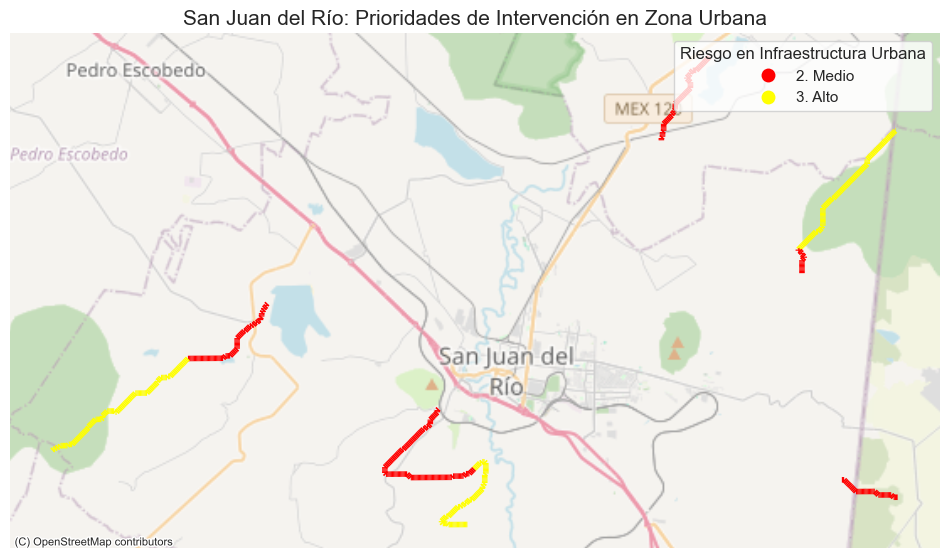

In [12]:
# 1. Refinamiento Extremo: Enfocándonos en el "corazón" del riesgo urbano
# Subimos el mínimo a 35 y bajamos el máximo a 65
gdf_foco_urbano = gdf[(gdf['indice_peligro'] > 35) & (gdf['indice_peligro'] <= 65)].copy()

# 2. Resumen estadístico del nuevo subconjunto
resumen_foco = gdf_foco_urbano.groupby('nivel_riesgo').size().reset_index(name='Total_Segmentos')
resumen_foco['Porcentaje_Relativo'] = (resumen_foco['Total_Segmentos'] / len(gdf_foco_urbano)) * 100

print(f"Base de datos final optimizada: {len(gdf_foco_urbano)} segmentos detectados.")
print("-" * 60)
print(resumen_foco.sort_values(by='nivel_riesgo', ascending=False).to_string(index=False))

# 3. Mapeo de precisión
fig, ax = plt.subplots(figsize=(12, 10))
gdf_foco_web = gdf_foco_urbano.to_crs(epsg=3857)

# Usamos una línea más gruesa para que resalten las calles afectadas
gdf_foco_web.plot(ax=ax, column='nivel_riesgo', cmap='autumn', linewidth=4, legend=True,
                  legend_kwds={'title': "Riesgo en Infraestructura Urbana"})

ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik, alpha=0.7)
plt.title('San Juan del Río: Prioridades de Intervención en Zona Urbana', fontsize=15)
ax.set_axis_off()
plt.show()


## Fase 6: Enfoque en Infraestructura Vial y Urbana

Tras el análisis macro, se observa que la acumulación natural de flujo domina los resultados periféricos. Para este reporte de **GEMCLU**, ajustamos el enfoque a:

1. **Escurrimientos de Primer Orden**: Filtramos flujos incipientes (Índice < 5) que ocurren directamente sobre pavimentos.
2. **Intersección con Vialidades**: Priorizamos tramos que, aunque menores en volumen, impactan la movilidad en la zona centro y oriente de SJR.
3. **Limpieza Visual**: Eliminamos los segmentos de gran longitud para resaltar los puntos críticos en esquinas y colectores.

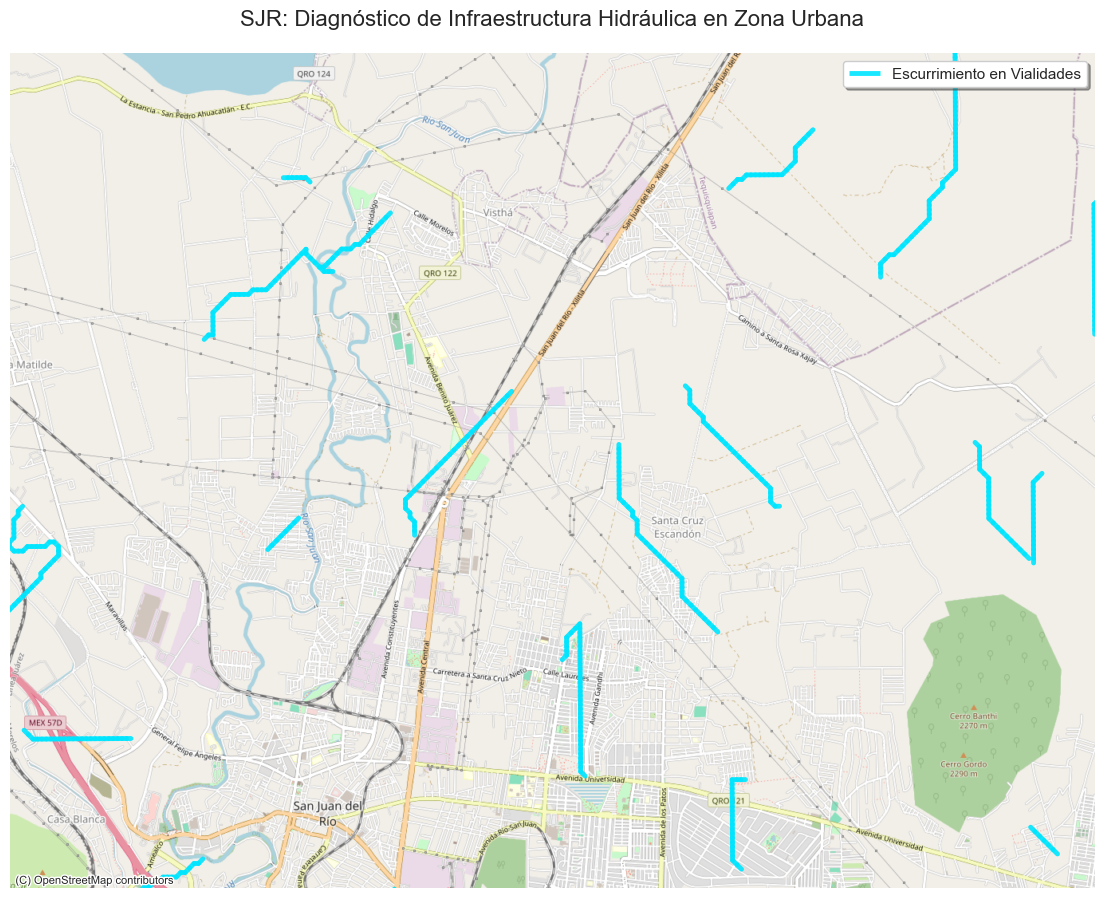

Visualización final optimizada con 4992 segmentos de riesgo.


In [20]:

gdf_vial = gdf[(gdf['indice_peligro'] > 0.5) & (gdf['indice_peligro'] <= 3)].copy()
gdf_vial = gdf_vial[gdf_vial['Shape_Leng'] < 150]

fig, ax = plt.subplots(figsize=(14, 14))
gdf_vial_web = gdf_vial.to_crs(epsg=3857)


gdf_vial_web.plot(ax=ax, 
                    color='#00e5ff', 
                    linewidth=3.5,     # Grosor aumentado para mayor impacto visual
                    alpha=0.9,         # Un poco más de opacidad
                    capstyle='round',  # Puntas redondeadas para un look más profesional
                    label='Escurrimiento en Vialidades')


ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik, zoom=14)

ax.set_xlim([-11135000, -11122000]) 
ax.set_ylim([2318000, 2328000]) 

plt.title('SJR: Diagnóstico de Infraestructura Hidráulica en Zona Urbana', fontsize=16, pad=20)
plt.legend(loc='upper right', frameon=True, shadow=True)
ax.set_axis_off()

plt.show()

print(f"Visualización final optimizada con {len(gdf_vial)} segmentos de riesgo.")

## Fase 7: Visualización Geoespacial Interactiva (Entregable Final)

Para maximizar la utilidad del análisis para la toma de decisiones en campo y la gestión de infraestructura, se desarrolló un **Visor Interactivo Web**. Esta herramienta permite una exploración dinámica de los resultados obtenidos en las fases anteriores.

### Características del Visor:
1. **Accesibilidad**: Generado en formato HTML autónomo, eliminando la necesidad de software GIS especializado para su visualización.
2. **Interactividad de Atributos**: Cada segmento de escurrimiento cuenta con un *popup* que detalla:
   - **Índice de Peligrosidad**: Valor cuantitativo del modelo.
   - **Nivel de Riesgo**: Clasificación cualitativa (Moderado, Alto, Crítico).
   - **Métricas Físicas**: Longitud del tramo en metros.
3. **Escala Urbana**: El mapa base permite realizar zoom a nivel de calle para identificar intersecciones específicas y activos de infraestructura civil en riesgo.


In [28]:
import folium

# 1. Preparar los datos (Usamos el filtro urbano que ya validamos)
# Convertimos a EPSG:4326 porque es el estándar para mapas web (lat/lon)
gdf_interactivo = gdf[(gdf['indice_peligro'] > 0.5) & (gdf['indice_peligro'] <= 15)].to_crs(epsg=4326)

# 2. Crear el mapa base centrado en SJR
m = folium.Map(location=[20.3889, -99.9961], zoom_start=14, tiles='OpenStreetMap')

# 3. Función para asignar colores según el riesgo
def get_color(indice):
    if indice <= 2: return '#00e5ff' # Moderado
    if indice <= 5: return '#ffff00' # Alto (Avenidas)
    return '#ff0000'                # Crítico

# 4. Agregar los tramos al mapa con Popups
for _, row in gdf_interactivo.iterrows():
    # Extraemos las coordenadas de la línea
    sim_geo = row['geometry']
    
    # Creamos la línea en el mapa
    folium.PolyLine(
        locations=[(p[1], p[0]) for p in sim_geo.coords],
        color=get_color(row['indice_peligro']),
        weight=4,
        opacity=0.8,
        tooltip=f"Riesgo: {row['nivel_riesgo']}",
        popup=(f"<b>Detalle de Riesgo</b><br>"
               f"Índice: {row['indice_peligro']:.2f}<br>"
               f"Longitud: {row['Shape_Leng']:.1f}m<br>"
               f"Prioridad: {row['nivel_riesgo']}")
    ).add_to(m)

# 5. Guardar el resultado como archivo HTML
m.save('Visor_Riesgo_SJR_GEMCLU.html')

print("¡Mapa interactivo generado con éxito! Busca el archivo 'Visor_Riesgo_SJR_GEMCLU.html' en tu carpeta.")

¡Mapa interactivo generado con éxito! Busca el archivo 'Visor_Riesgo_SJR_GEMCLU.html' en tu carpeta.
